In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gymnasium as gym
from gymnasium import spaces
import random, pickle, json, datetime
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
random.seed(42)
print("Semua library berhasil diimport!")

Semua library berhasil diimport!


## Cell 1 — Import Library

### Fungsi
Memuat semua library yang dipakai di notebook dan mengunci nilai acak (`seed = 42`) supaya hasil bisa direproduksi.

### Library yang dipakai
| Library | Dipakai untuk |
|---|---|
| `numpy` | Operasi angka dan **Q-table** (array 2 dimensi) |
| `pandas` | Membaca CSV dan mengolah data per `Reactor_Run_ID` |
| `matplotlib`, `seaborn` | Semua visualisasi (heatmap, kurva belajar, dll.) |
| `gymnasium` | Kerangka standar membuat **environment RL** (`gym.Env`, `spaces`) |
| `random`, `pickle`, `json`, `datetime` | Pilih run acak, simpan model `.pkl`, cetak JSON, catat waktu training |

### Kenapa seed dikunci?
RL penuh unsur acak (pilihan aksi eksplorasi, pemilihan run). Dengan `seed = 42`, urutan acak selalu sama, jadi hasil bisa diulang dan dibandingkan.

### Output
Satu baris: `Semua library berhasil diimport!`. Jika ada error `ModuleNotFoundError`, install dulu dengan `pip install gymnasium`.

In [ ]:
# Load dataset (pastikan file sudah ada di Colab)
df = pd.read_csv('reactor_sample_5k.csv')

# Sort per run (PRD 9.4) agar urutan waktu benar
df = df.sort_values(['Reactor_Run_ID', 'Timestamp_min']).reset_index(drop=True)

print("Ukuran dataset:", df.shape)
print("Missing value:", df.isnull().sum().sum())
print(f"Jumlah episode (Reactor_Run_ID): {df['Reactor_Run_ID'].nunique()}")
print(f"Rata-rata langkah per episode: {len(df) / df['Reactor_Run_ID'].nunique():.1f}")
display(df.describe())

Ukuran dataset: (4901, 7)
Missing value: 0
Jumlah episode (Reactor_Run_ID): 27
Rata-rata langkah per episode: 181.5


,Timestamp_min,Reactor_Temp_C,Jacket_Flow_Rate_L_min,Pressure_atm,Reactant_A_Conc_mol_L,Product_B_Conc_mol_L,Reactor_Run_ID
count,4901.000000,4901.000000,4901.000000,4901.000000,4901.000000,4901.000000,4901.000000
mean,2489.644970,88.206101,1012.611916,3.192659,1.401363,1.098000,14.552132
std,1456.621267,7.898097,8.740077,0.157271,0.778582,0.778344,7.580048
min,0.000000,60.500000,936.000000,2.220000,0.000000,0.000000,1.000000
25%,1225.000000,84.850000,1010.000000,3.170000,0.720000,0.440000,8.000000
50%,2450.000000,85.100000,1014.000000,3.200000,1.600000,0.900000,15.000000
75%,3775.000000,90.000000,1016.000000,3.220000,2.060000,1.770000,21.000000
max,5000.000000,110.000000,1063.000000,4.490000,2.500000,2.500000,27.000000


## Cell 2 — Load Dataset dan Pemeriksaan Awal

### Fungsi
Membaca `reactor_sample_5k.csv`, mengurutkan data, lalu memeriksa kualitas data.

### Cara kerja
1. `pd.read_csv` membaca file.
2. `sort_values(['Reactor_Run_ID', 'Timestamp_min'])` mengurutkan data **per run, lalu per waktu**.
   Ini wajib menurut PRD 9.4. Dalam RL, urutan waktu adalah urutan kejadian. Jika tertukar, "langkah berikutnya" tidak bermakna.
3. Mencetak ukuran data, jumlah missing value, jumlah episode, dan statistik deskriptif (`describe()`).

### Inti
Di RL, satu **`Reactor_Run_ID` = satu episode** (satu siklus hidup batch reaktor). Dataset ini terdiri dari beberapa episode yang masing-masing punya panjang berbeda.

### Output yang diharapkan
- Ukuran data: **4901 baris x 7 kolom**
- Missing value: **0**
- Jumlah episode: **27 run**
- Rata-rata langkah per episode: **sekitar 181,5** (panjang run berkisar 100 sampai 290)
- Tabel statistik: suhu berkisar 60,5 sampai 110 °C (median sekitar 85 °C), flow sekitar 936 sampai 1063 L/min.

### Kenapa penting untuk ttahap berikutnya?
- Median suhu sekitar 85 °C menjadi dasar **target suhu simulasi** di Cell 5.
- Flow sekitar 1000 L/min menentukan batas diskretisasi di Cell 6. Kode contoh dosen memakai batas 0 sampai 50, yang tidak cocok dengan data ini.

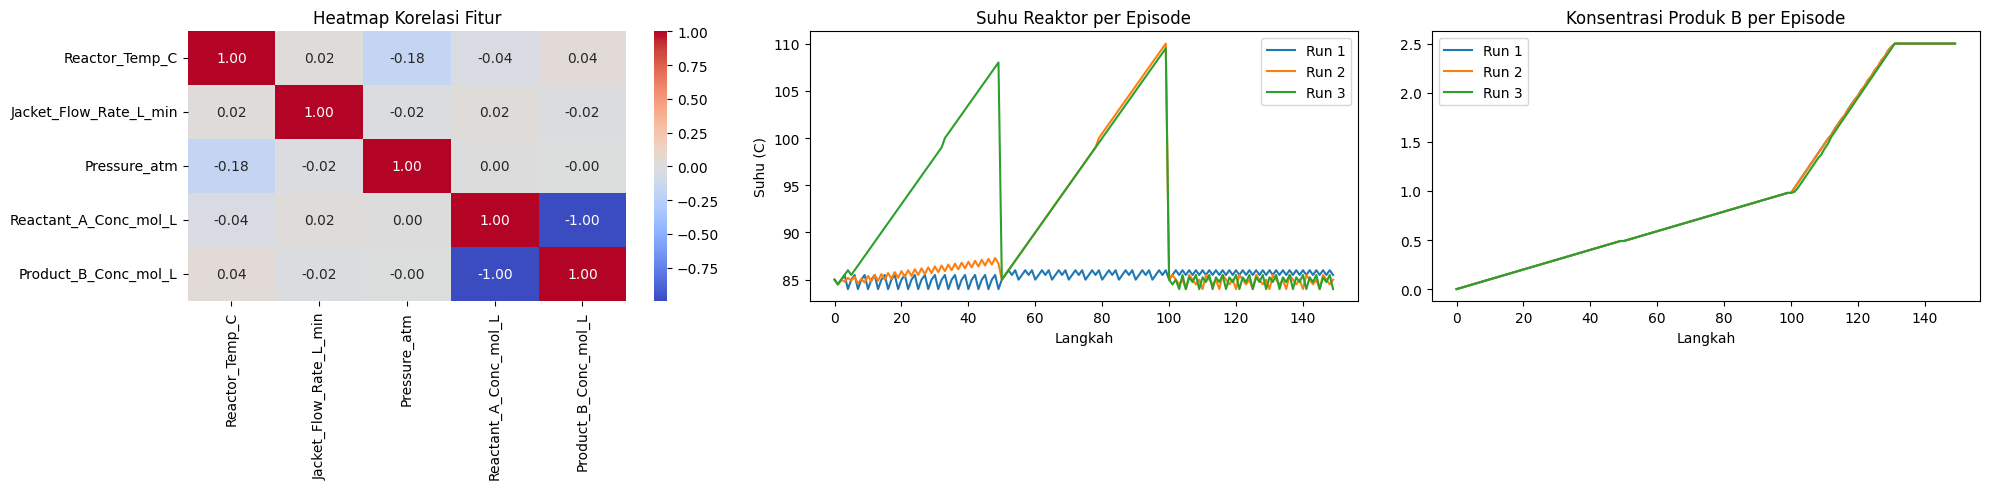

In [ ]:
fitur = ['Reactor_Temp_C', 'Jacket_Flow_Rate_L_min', 'Pressure_atm',
         'Reactant_A_Conc_mol_L', 'Product_B_Conc_mol_L']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Heatmap korelasi
sns.heatmap(df[fitur].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0])
axes[0].set_title('Heatmap Korelasi Fitur')

# Suhu 3 episode pertama
for run_id in df['Reactor_Run_ID'].unique()[:3]:
    subset = df[df['Reactor_Run_ID'] == run_id]
    axes[1].plot(subset['Timestamp_min'].values - subset['Timestamp_min'].min(),
                 subset['Reactor_Temp_C'].values, label=f'Run {run_id}')
axes[1].set_title('Suhu Reaktor per Episode')
axes[1].set_xlabel('Langkah')
axes[1].set_ylabel('Suhu (C)')
axes[1].legend()

# Product B 3 episode pertama
for run_id in df['Reactor_Run_ID'].unique()[:3]:
    subset = df[df['Reactor_Run_ID'] == run_id]
    axes[2].plot(subset['Timestamp_min'].values - subset['Timestamp_min'].min(),
                 subset['Product_B_Conc_mol_L'].values, label=f'Run {run_id}')
axes[2].set_title('Konsentrasi Produk B per Episode')
axes[2].set_xlabel('Langkah')
axes[2].legend()

plt.tight_layout()
plt.show()

## Cell 3 — Visualisasi Data (Heatmap Korelasi dan Time-Series)

### Fungsi
Memahami pola data sebelum membangun environment RL. Ada 3 grafik.

### Penjelasan tiap grafik
1. **Heatmap korelasi** (`sns.heatmap(df[fitur].corr())`)
   Menampilkan hubungan linear antar 5 variabel. Warna merah berarti berkorelasi positif, biru berarti negatif, dan angkanya berkisar -1 sampai 1.
   Dipakai untuk melihat variabel mana yang bergerak bersama (misalnya tekanan dengan suhu, reaktan A dengan produk B).
   **Catatan:** korelasi bukan sebab-akibat. Ini alasan hubungan flow ke suhu di environment tidak diambil dari data, tetapi dibuat sebagai asumsi (lihat Cell 5).
2. **Suhu per episode**: bentuk perjalanan suhu satu batch, termasuk lonjakan (anomali) bila ada.
3. **Produk B per episode**: yield produk naik seiring waktu karena reaktan A berubah menjadi produk B.

### Inti
Sebelum melatih agen, kita harus tahu seperti apa "dunia" yang akan dikendalikan. Sumbu X memakai langkah relatif (`Timestamp - Timestamp.min()`) supaya semua episode dimulai dari 0 dan bisa dibandingkan.

### Output
Satu gambar berisi tiga panel (heatmap, kurva suhu, kurva produk B).

In [ ]:
# Split berdasarkan Reactor_Run_ID (satu run tidak boleh ada di train dan test)
semua_run = [int(r) for r in df['Reactor_Run_ID'].unique()]
random.shuffle(semua_run)

test_runs = sorted(semua_run[:5])       # 5 run untuk test
train_runs = sorted(semua_run[5:])      # sisanya untuk training

print("Run training:", train_runs)
print("Run test    :", test_runs)

# Simpan data tiap run dalam dictionary
data_run = {r: df[df['Reactor_Run_ID'] == r].reset_index(drop=True) for r in semua_run}

Run training: [1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 14, 15, 16, 18, 19, 21, 22, 23, 24, 25, 26]
Run test    : [10, 13, 17, 20, 27]


## Cell 4 — Pembagian Data Training dan Test (Split per Run)

### Fungsi
Memisahkan run menjadi **22 run untuk training** dan **5 run untuk test**.

### Cara kerja
1. Ambil daftar semua `Reactor_Run_ID` (27 run).
2. Acak urutannya dengan `random.shuffle`.
3. 5 run pertama menjadi `test_runs`, sisanya `train_runs`.
4. `data_run` adalah dictionary `{run_id: DataFrame run tersebut}` supaya mudah diambil saat training.

### Kenapa split per Run ID, bukan acak per baris?
PRD 9.5 memperingatkan bahwa data ini time-series dan multi-run. Jika dipecah acak per baris, baris yang berdekatan (yang sangat mirip) bisa masuk train dan test sekaligus. Akibatnya skor tampak terlalu bagus (*data leakage*).
Dengan split per run, agen **diuji pada batch yang belum pernah dilihatnya sama sekali**. Ini yang sesuai dengan kondisi nyata: aplikasi nanti akan menerima kondisi batch baru.

### Kenapa tidak cross-validation?
Hanya ada 27 run dan Q-Learning cukup mahal diulang berkali-kali. Satu split sudah cukup untuk tugas ini. Kekurangannya, hasil bisa berubah sedikit tergantung run mana yang kebetulan menjadi test.

### Output
Daftar nomor run training dan run test yang dicetak.

In [ ]:
# ===== ASUMSI SIMULASI (wajib didokumentasikan, PRD bagian 11 & 12) =====
TARGET_TEMP = 85.0      # target suhu simulasi (median dataset ~85), BUKAN batas keselamatan
FLOW_DELTA = 20.0       # perubahan flow per aksi (L/min)
FLOW_OFFSET_MAX = 100.0 # batas total perubahan flow dari data historis
K_SUHU = 0.05           # asumsi: flow naik 1 L/min -> suhu turun 0.05 C (tidak divalidasi eksperimen)

class BatchReactorEnv(gym.Env):
    """
    Lingkungan simulasi reaktor batch.
    State : [Reactor_Temp_C, Jacket_Flow, Pressure, Reactant_A, Product_B]
    Action: 0 = Decrease Jacket Flow, 1 = Maintain, 2 = Increase Jacket Flow
    Reward: makin dekat ke TARGET_TEMP makin besar
    Transisi: data historis (replay) + efek action pada flow dan suhu (ASUMSI)
    """
    def __init__(self, data):
        super().__init__()
        self.data = data.reset_index(drop=True)
        self.max_steps = len(self.data) - 1
        self.observation_space = spaces.Box(
            low=np.array([0, 0, 0, 0, 0], dtype=np.float32),
            high=np.array([200, 2000, 10, 5, 5], dtype=np.float32), dtype=np.float32)
        self.action_space = spaces.Discrete(3)
        self.current_step = 0
        self.offset = 0.0   # total perubahan flow akibat action agent

    def _get_state(self):
        row = self.data.iloc[self.current_step]
        return np.array([
            row['Reactor_Temp_C'] - K_SUHU * self.offset,
            row['Jacket_Flow_Rate_L_min'] + self.offset,
            row['Pressure_atm'],
            row['Reactant_A_Conc_mol_L'],
            row['Product_B_Conc_mol_L']], dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.offset = 0.0
        return self._get_state(), {}

    def step(self, action):
        # Ubah flow sesuai action (dibatasi)
        perubahan = (action - 1) * FLOW_DELTA
        offset_baru = self.offset + perubahan
        mentok = abs(offset_baru) > FLOW_OFFSET_MAX
        self.offset = float(np.clip(offset_baru, -FLOW_OFFSET_MAX, FLOW_OFFSET_MAX))

        # Maju satu langkah
        self.current_step += 1
        next_state = self._get_state()

        # Reward
        error = abs(next_state[0] - TARGET_TEMP)
        reward = -0.5 * error              # makin jauh dari target makin buruk
        if error <= 2.0:
            reward += 1.0                  # bonus jika dalam toleransi +-2 C
        if action != 1:
            reward -= 0.05                 # penalti kecil jika mengubah flow
        if mentok:
            reward -= 0.5                  # penalti jika flow mentok batas

        terminated = self.current_step >= self.max_steps
        return next_state, reward, terminated, False, {'error': error}

print("Environment siap. Target suhu simulasi:", TARGET_TEMP, "C")

Environment siap. Target suhu simulasi: 85.0 C


## Cell 5 — Environment RL (`BatchReactorEnv`)

### Fungsi
Membuat **lingkungan simulasi** tempat agen belajar. Environment menerima aksi dari agen, lalu mengembalikan kondisi reaktor berikutnya (*next state*) dan nilai *reward*.

### Komponen RL
| Komponen | Isi di kode ini |
|---|---|
| **State** | `[suhu, jacket flow, tekanan, reaktan A, produk B]` |
| **Action** | 0 = Decrease, 1 = Maintain, 2 = Increase jacket flow |
| **Reward** | Makin dekat suhu ke target, makin besar |
| **Episode** | Satu `Reactor_Run_ID`; selesai di langkah terakhir run |

### Cara kerja `step(action)`
1. **Ubah flow.** Perubahan = (action - 1) x 20 L/min. Totalnya (`offset`) dibatasi maksimal +-100 L/min.
2. **Maju satu langkah waktu.** Tekanan, reaktan A, dan produk B diambil dari **data historis** (replay). Flow dan suhu dimodifikasi oleh aksi agen.
3. **Efek ke suhu:** suhu = suhu data - 0,05 x offset. Artinya flow naik, suhu turun (pendinginan lebih banyak).
4. **Hitung reward:**
   - `-0,5 x |suhu - target|` : makin jauh dari target makin buruk
   - `+1` jika selisih <= 2 °C : bonus berada dalam toleransi
   - `-0,05` jika mengubah flow : penalti kecil agar tidak sembarangan mengubah kontrol
   - `-0,5` jika flow mentok batas : penalti
   - Contoh: selisih 0 °C reward +1; selisih 2 °C reward 0; selisih 10 °C reward -5.

### Inti: ini SIMULASI, bukan reaktor nyata (PRD bagian 11.6 dan 12)
Dataset bersifat observasional. Data hanya mencatat apa yang terjadi, **bukan** hasil eksperimen "kalau flow dinaikkan, suhu pasti turun X". Karena itu hubungan aksi ke suhu di sini adalah **asumsi simulasi**:
- `TARGET_TEMP = 85` : dari median dataset, **bukan batas keselamatan**
- `FLOW_DELTA = 20`, `FLOW_OFFSET_MAX = 100`, `K_SUHU = 0.05` : asumsi tim, tidak divalidasi eksperimen

### Kenapa memilih "replay data + aturan buatan", bukan pendekatan lain?
| Pilihan transisi (PRD 12.3) | Alasan tidak dipakai |
|---|---|
| Model ML (Random Forest) memprediksi next state | Model dilatih dari data observasional, jadi mengubah input flow lalu menganggap hasilnya sebab-akibat adalah asumsi yang berisiko. Selain itu, model itu dikerjakan anggota lain (ML Engineer 1). |
| Persamaan fisika/kimia reaktor penuh | Butuh parameter reaktor (kapasitas panas, kinetika, dll.) yang tidak ada. |
| **Replay + aturan sederhana (dipakai)** | Paling jujur dan mudah dijelaskan: asumsinya eksplisit dan bisa diubah di satu tempat. |

### Output
`Environment siap. Target suhu simulasi: 85.0 C`

In [ ]:
# Hyperparameter
learning_rate = 0.2
discount_factor = 0.8
max_epsilon = 1.0
min_epsilon = 0.02
decay_rate = 0.0007
n_episodes = 8000
n_actions = 3

# Diskretisasi state (suhu dihitung sebagai selisih terhadap target)
bounds = [(-10, 10),     # suhu - target
          (900, 1100),   # flow
          (2.0, 5.0),    # tekanan
          (0.0, 2.5),    # reaktan A
          (0.0, 2.5)]    # produk B
n_bins = [21, 10, 3, 3, 3]

Q_table = np.zeros((np.prod(n_bins), n_actions))
visit_count = np.zeros((np.prod(n_bins), n_actions))

def discretize_state(state):
    nilai = [state[0] - TARGET_TEMP, state[1], state[2], state[3], state[4]]
    indices = []
    for val, (low, high), n_bin in zip(nilai, bounds, n_bins):
        normalized = np.clip((val - low) / (high - low), 0, 0.9999)
        indices.append(int(normalized * n_bin))
    return np.ravel_multi_index(indices, n_bins)

print("Shape Q-table:", Q_table.shape)

Shape Q-table: (5670, 3)


## Cell 6 — Hyperparameter, Q-Table, dan Diskretisasi State

### Fungsi
Menyiapkan "buku catatan" agen (**Q-table**) dan pengaturan belajarnya (hyperparameter).

### Q-table
Tabel berukuran **jumlah state x 3 aksi**. Isi `Q[s, a]` adalah perkiraan seberapa bagus mengambil aksi `a` pada state `s` untuk jangka panjang. Awalnya semua 0, lalu diisi saat training.

### Kenapa state harus didiskretkan?
Suhu, flow, dan lainnya berupa angka kontinu (tak hingga kemungkinan). Q-table hanya bisa mencatat sejumlah state yang terbatas, sehingga angka kontinu dipotong menjadi **bin** (kotak-kotak):

| Variabel | Rentang | Jumlah bin | Keterangan |
|---|---|---|---|
| Suhu - target | -10 sampai +10 °C | 21 | sekitar 0,95 °C, cukup halus untuk melacak target |
| Jacket flow | 900 sampai 1100 | 10 | Lebar 20 L/min = sama dengan satu langkah aksi |
| Tekanan | 2 sampai 5 atm | 3 | Kasar cukup |
| Reaktan A | 0 sampai 2,5 | 3 | Menandakan fase proses |
| Produk B | 0 sampai 2,5 | 3 | Menandakan fase proses |

Total state = 21 x 10 x 3 x 3 x 3 = **5.670**, jadi Q-table berukuran (5670, 3).
Suhu dihitung sebagai **selisih terhadap target**, bukan suhu mentah, supaya target bisa diubah tanpa mengubah struktur tabel.

### Fungsi `discretize_state`
Menormalkan tiap nilai ke rentang 0 sampai 1, mengalikannya dengan jumlah bin untuk mendapat nomor bin, lalu `np.ravel_multi_index` menggabungkan 5 nomor bin menjadi satu nomor baris Q-table. Nilai di luar rentang dipotong ke bin terujung (`np.clip`).

### Hyperparameter
| Parameter | Nilai | Arti |
|---|---|---|
| `learning_rate` (alpha) | 0,2 | Seberapa cepat Q-value diperbarui oleh pengalaman baru |
| `discount_factor` (gamma) | 0,8 | Seberapa penting reward masa depan (0,8 berarti agak berorientasi jangka dekat) |
| `epsilon` | 1,0 turun ke 0,02 | Peluang memilih aksi acak (eksplorasi) |
| `decay_rate` | 0,0007 | Kecepatan penurunan epsilon |
| `n_episodes` | 8000 | Banyak episode training |

Nilai ini dipilih lewat uji coba beberapa kombinasi pada data ini (gamma lebih kecil dan episode lebih banyak memberi hasil lebih stabil). Tabel eksperimen hyperparameter bisa dibuat sebagai pengembangan.

### Output
`Shape Q-table: (5670, 3)`

In [ ]:
rewards_per_episode = []
mae_per_episode = []
epsilon_history = []
epsilon = max_epsilon

print("Memulai training Q-Learning...")
for episode in range(n_episodes):
    # Pilih satu run training secara acak sebagai episode
    env = BatchReactorEnv(data_run[random.choice(train_runs)])
    state, _ = env.reset()
    done = False
    total_reward = 0
    errors = []

    while not done:
        state_idx = discretize_state(state)

        # Epsilon-greedy
        if np.random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q_table[state_idx, :])

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        next_state_idx = discretize_state(next_state)

        # Update Q-table (rumus Bellman)
        Q_table[state_idx, action] += learning_rate * (
            reward + discount_factor * np.max(Q_table[next_state_idx, :])
            - Q_table[state_idx, action])
        visit_count[state_idx, action] += 1

        state = next_state
        total_reward += reward
        errors.append(info['error'])

    rewards_per_episode.append(total_reward / len(errors))   # reward per step
    mae_per_episode.append(np.mean(errors))
    epsilon_history.append(epsilon)
    epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)

    if (episode + 1) % 1000 == 0:
        print(f"Episode {episode+1:5d}/{n_episodes} | Reward/step: {np.mean(rewards_per_episode[-1000:]):.3f} | Epsilon: {epsilon:.3f}")

print("Training selesai!")

Memulai training Q-Learning...
Episode  1000/8000 | Reward/step: -2.037 | Epsilon: 0.507
Episode  2000/8000 | Reward/step: -1.438 | Epsilon: 0.262
Episode  3000/8000 | Reward/step: -1.255 | Epsilon: 0.140
Episode  4000/8000 | Reward/step: -1.226 | Epsilon: 0.080
Episode  5000/8000 | Reward/step: -1.204 | Epsilon: 0.050
Episode  6000/8000 | Reward/step: -1.137 | Epsilon: 0.035
Episode  7000/8000 | Reward/step: -1.183 | Epsilon: 0.027
Episode  8000/8000 | Reward/step: -1.161 | Epsilon: 0.024
Training selesai!


## Cell 7 — Training Q-Learning

### Fungsi
Inti proses belajar: agen mencoba aksi berulang kali di environment dan memperbarui Q-table dari pengalamannya.

### Algoritma: Q-Learning (tabular, off-policy)
Alurnya setiap langkah:
1. Lihat state saat ini lalu diskretkan menjadi nomor baris Q-table.
2. **Epsilon-greedy:** dengan peluang epsilon pilih aksi **acak** (eksplorasi); selain itu pilih aksi dengan Q-value tertinggi (eksploitasi).
3. Jalankan aksi lalu terima state berikutnya dan reward.
4. Perbarui Q-table dengan **persamaan Bellman**:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma \max_{a'} Q(s',a') - Q(s,a) \right]$$

   Artinya: nilai lama digeser sedikit ke arah (reward sekarang + nilai terbaik yang mungkin di langkah berikutnya).
5. Ulangi sampai episode (satu run) selesai, lalu mulai episode baru dengan run training lain yang dipilih acak.

Epsilon diturunkan tiap episode (`eksponensial`): awalnya hampir selalu mencoba-coba, lama-lama makin sering memakai yang sudah dipelajari. Di akhir training epsilon sekitar 0,02.

### Kenapa Q-Learning? Kenapa bukan algoritma lain?
| Algoritma | Alasan tidak dipilih |
|---|---|
| **Q-Learning (dipilih)** | Aksi hanya 3 (diskret), data kecil (4.901 baris), hasilnya berupa tabel yang transparan dan mudah dijelaskan. Sesuai materi dosen. File model hanya `.pkl` berisi array. |
| SARSA | Mirip, tetapi *on-policy* (belajar dari aksi yang benar-benar diambil, termasuk aksi acak). Lebih konservatif; tidak ada kebutuhan itu di sini, sedangkan Q-Learning langsung belajar kebijakan optimal. |
| DQN (Deep Q-Network) | Cocok untuk state kontinu atau sangat banyak, tetapi butuh PyTorch/TensorFlow, lebih sulit dijelaskan, dan lebih berat untuk backend. Berlebihan untuk 5 variabel dan 3 aksi. |
| PPO / A2C (policy gradient) | Lebih kompleks, butuh library tambahan (Stable-Baselines3), dan tidak perlu untuk action space sekecil ini. |
| Monte Carlo | Harus menunggu episode selesai baru belajar, varians tinggi. Q-Learning belajar tiap langkah. |
| Dynamic Programming | Butuh model transisi yang diketahui secara pasti. Di sini transisinya hanya asumsi simulasi dan datanya replay. |

### Mengapa reward per step dicatat, bukan total?
Panjang run berbeda-beda (100 sampai 290 langkah), jadi total reward tidak adil dibandingkan. `reward / jumlah langkah` membuat episode bisa dibandingkan.

### Output
Log tiap 1000 episode: `Reward/step` yang membaik (misal dari sekitar -2,0 ke sekitar -1,15) dan `Epsilon` yang turun. Reward training masih negatif karena (a) masih ada eksplorasi acak dan (b) run anomali punya suhu jauh dari target yang tidak bisa dikoreksi penuh.

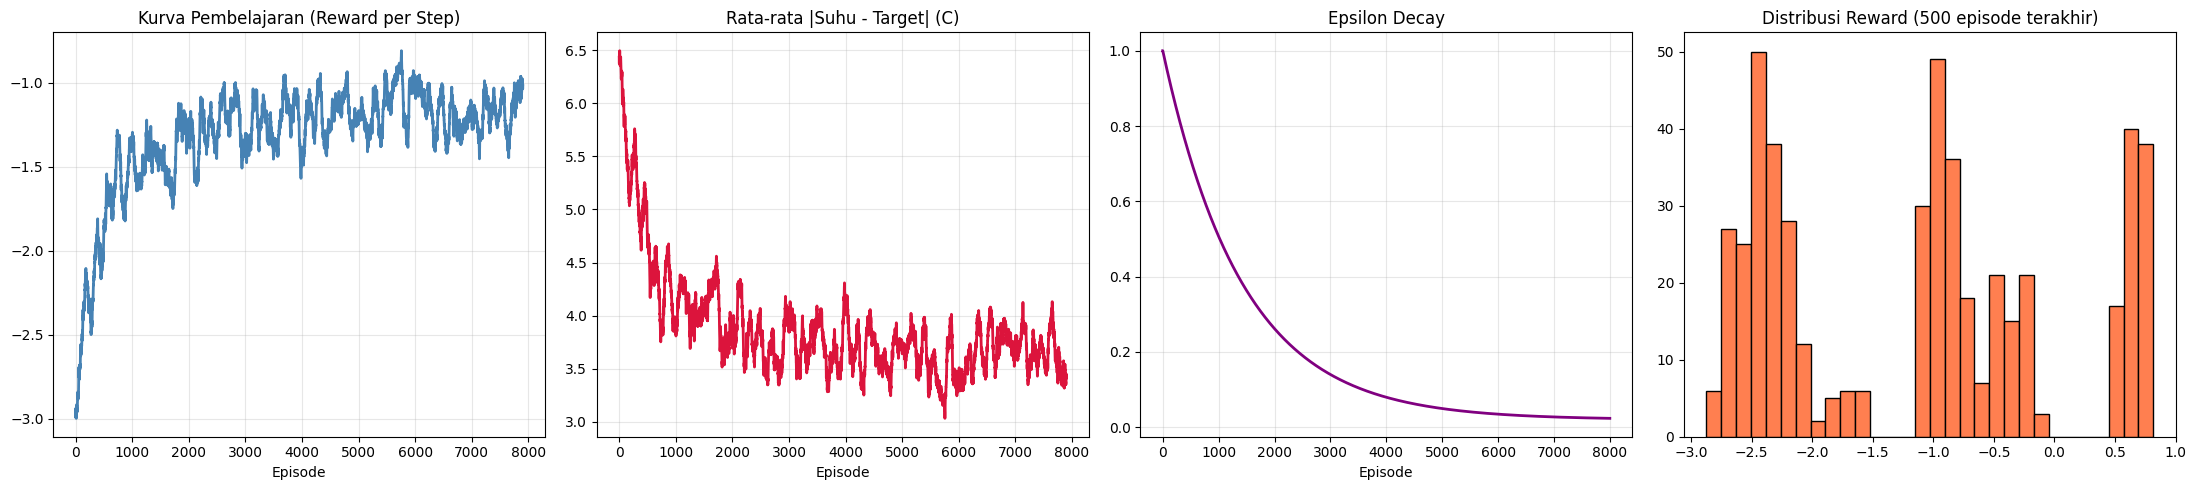

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
window = 100

smooth_r = np.convolve(rewards_per_episode, np.ones(window)/window, mode='valid')
axes[0].plot(smooth_r, color='steelblue', linewidth=2)
axes[0].set_title('Kurva Pembelajaran (Reward per Step)')

smooth_m = np.convolve(mae_per_episode, np.ones(window)/window, mode='valid')
axes[1].plot(smooth_m, color='crimson', linewidth=2)
axes[1].set_title('Rata-rata |Suhu - Target| (C)')

axes[2].plot(epsilon_history, color='purple', linewidth=2)
axes[2].set_title('Epsilon Decay')

axes[3].hist(rewards_per_episode[-500:], bins=30, color='coral', edgecolor='black')
axes[3].set_title('Distribusi Reward (500 episode terakhir)')

for ax in axes[:3]:
    ax.set_xlabel('Episode')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Cell 8 — Plot Kurva Pembelajaran

### Fungsi
Menunjukkan **apakah agen benar-benar belajar** selama training.

### Penjelasan 4 panel
1. **Kurva Pembelajaran (reward per step):** reward rata-rata (moving average 100 episode agar halus). Jika naik lalu mendatar, berarti agen belajar dan mulai konvergen.
2. **Rata-rata |Suhu - Target|:** rata-rata jarak suhu ke target tiap episode. Harus **turun**; ini ukuran yang lebih mudah dipahami daripada reward.
3. **Epsilon decay:** kurva peluruhan eksplorasi, dari 1,0 (sepenuhnya acak) turun mendekati 0,02 (hampir selalu memakai Q-table).
4. **Distribusi reward 500 episode terakhir:** sebaran hasil di akhir training; makin sempit dan makin ke kanan berarti makin stabil.

### Cara membaca
- Awal: kurva rendah dan epsilon tinggi karena agen masih mencoba-coba.
- Tengah: reward naik cepat saat Q-table terisi.
- Akhir: mendatar. Artinya tidak banyak lagi yang bisa dipelajari dengan konfigurasi ini.

### Catatan untuk presentasi
Kurva ini berasal dari data **training** (yang masih ada aksi acak). Penilaian sebenarnya ada di Cell 9, pada run test yang belum pernah dilihat agen.

EVALUASI PADA RUN TEST: [10, 13, 17, 20, 27]


,Reward/Step,MAE ke Target (C),% Step dalam +-2C
Agen Q-Learning,-0.534,2.590,79.595
Tanpa kontrol (Maintain),-1.035,3.567,74.863
Acak,-2.346,5.256,34.628
Aturan sederhana,-0.541,2.446,80.180


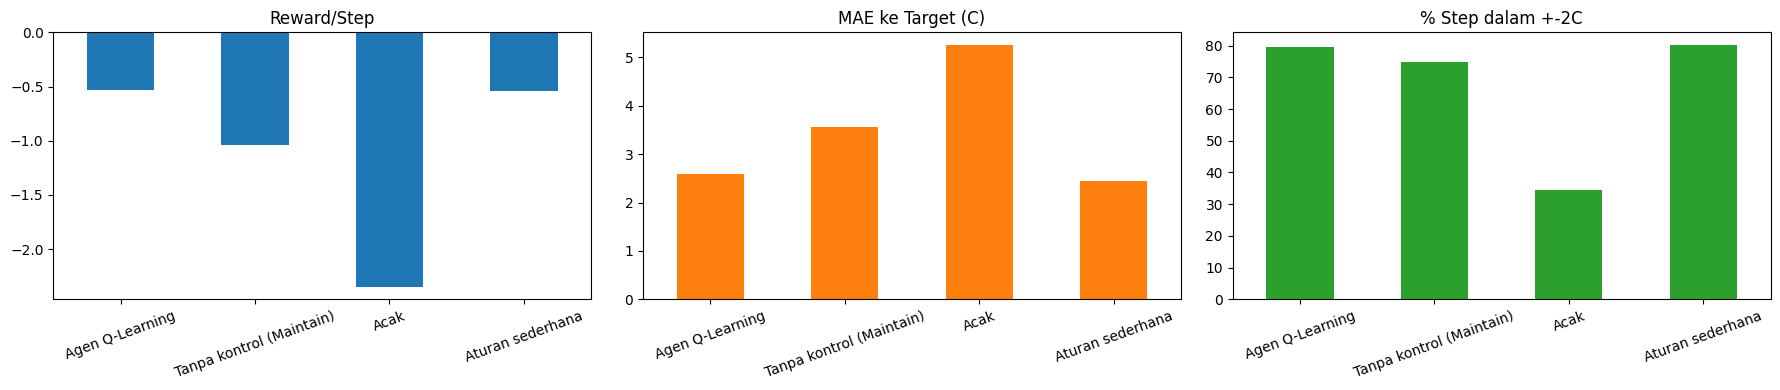

In [ ]:
def jalankan_policy(data, policy):
    """Jalankan satu run dengan policy tertentu, kembalikan hasilnya."""
    env = BatchReactorEnv(data)
    state, _ = env.reset()
    done = False
    suhu, flow_offset, aksi, errors, total_reward = [state[0]], [0.0], [], [], 0
    while not done:
        action = policy(state)
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        suhu.append(state[0]); flow_offset.append(env.offset)
        aksi.append(action); errors.append(info['error']); total_reward += reward
    return {'suhu': suhu, 'flow': flow_offset, 'aksi': aksi,
            'reward_step': total_reward / len(errors),
            'mae': np.mean(errors),
            'in_band': np.mean(np.array(errors) <= 2.0)}

# Policy yang dibandingkan
policy_agen   = lambda s: int(np.argmax(Q_table[discretize_state(s), :]))
policy_diam   = lambda s: 1
policy_acak   = lambda s: random.randint(0, 2)
policy_aturan = lambda s: 2 if s[0] > TARGET_TEMP + 0.5 else (0 if s[0] < TARGET_TEMP - 0.5 else 1)

daftar_policy = {'Agen Q-Learning': policy_agen, 'Tanpa kontrol (Maintain)': policy_diam,
                 'Acak': policy_acak, 'Aturan sederhana': policy_aturan}

hasil = {}
for nama, pol in daftar_policy.items():
    ulang = 20 if nama == 'Acak' else 1
    r = [jalankan_policy(data_run[run], pol) for run in test_runs for _ in range(ulang)]
    hasil[nama] = {'Reward/Step': np.mean([x['reward_step'] for x in r]),
                   'MAE ke Target (C)': np.mean([x['mae'] for x in r]),
                   '% Step dalam +-2C': 100 * np.mean([x['in_band'] for x in r])}

tabel_hasil = pd.DataFrame(hasil).T.round(3)
print("EVALUASI PADA RUN TEST:", test_runs)
display(tabel_hasil)

tabel_hasil[['Reward/Step', 'MAE ke Target (C)', '% Step dalam +-2C']].plot(
    kind='bar', subplots=True, layout=(1, 3), figsize=(18, 4), legend=False, rot=20)
plt.tight_layout()
plt.show()

## Cell 9 — Evaluasi Agen vs Baseline pada Run Test

### Fungsi
Mengukur kualitas agen pada **5 run test** (tidak dipakai saat training) dan membandingkannya dengan strategi lain.

### Cara kerja
`jalankan_policy(data, policy)` menjalankan satu run penuh dengan strategi tertentu, lalu mencatat suhu, perubahan flow, aksi, dan error. Untuk agen, aksi diambil **tanpa eksplorasi** (`np.argmax` dari Q-table).

### Pembanding (baseline), sesuai PRD 11.8
| Strategi | Arti |
|---|---|
| **Agen Q-Learning** | Memakai Q-table hasil training |
| **Tanpa kontrol (Maintain)** | Selalu Maintain, yaitu kondisi data historis apa adanya |
| **Acak** | Memilih aksi acak (diulang 20 kali dirata-rata agar adil) |
| **Aturan sederhana** | Jika suhu > target + 0,5 naikkan flow; jika < target - 0,5 turunkan flow |

### Metrik
- **Reward/Step**: makin tinggi makin baik
- **MAE ke target (°C)**: rata-rata jarak suhu ke target, makin kecil makin baik
- **% step dalam +-2 °C**: persentase waktu suhu berada dalam toleransi

### Hasil yang diharapkan (contoh dari pengujian)
| Strategi | MAE ke target |
|---|---|
| Agen Q-Learning | sekitar 2,5 °C |
| Tanpa kontrol | sekitar 3,6 °C |
| Acak | sekitar 5,3 °C |
| Aturan sederhana | sekitar 2,4 °C |

### Interpretasi (jujur)
- Agen **jauh lebih baik dari acak dan dari tanpa kontrol**, jadi agen memang belajar.
- Agen **hampir setara** dengan aturan sederhana, belum mengalahkannya. Ini wajar: Q-Learning tabular dengan diskretisasi kasar pada lingkungan sederhana. Aturan sederhana memang sudah hampir optimal untuk tugas "jaga suhu dekat target".
- Nilai ini adalah hasil di **simulasi**, bukan performa pada reaktor nyata.

### Output
Tabel hasil dan 3 grafik batang perbandingan (reward, MAE, % dalam toleransi).

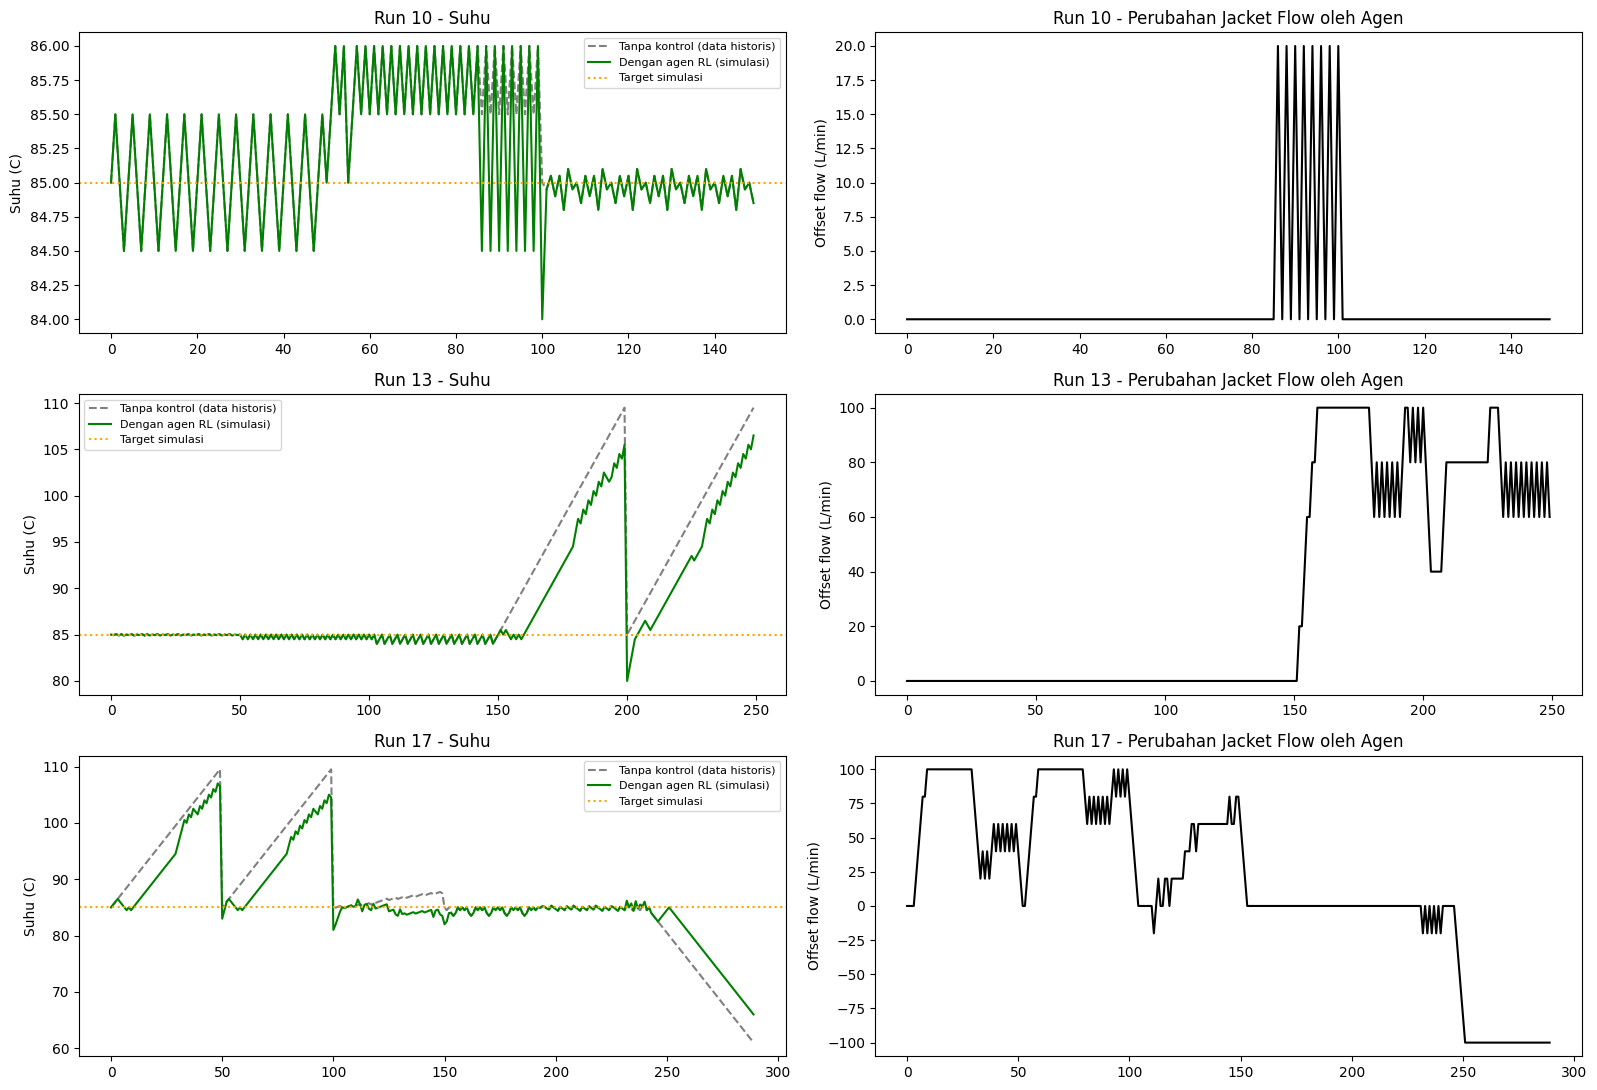

Jumlah aksi agen pada run test pertama: {'Decrease': np.int64(8), 'Maintain': np.int64(133), 'Increase': np.int64(8)}


In [ ]:
# Uji agen di lingkungan: suhu dengan agen vs tanpa kontrol
fig, axes = plt.subplots(3, 2, figsize=(16, 11))

for i, run in enumerate(test_runs[:3]):
    agen = jalankan_policy(data_run[run], policy_agen)
    diam = jalankan_policy(data_run[run], policy_diam)

    axes[i, 0].plot(diam['suhu'], '--', color='gray', label='Tanpa kontrol (data historis)')
    axes[i, 0].plot(agen['suhu'], color='green', label='Dengan agen RL (simulasi)')
    axes[i, 0].axhline(TARGET_TEMP, color='orange', linestyle=':', label='Target simulasi')
    axes[i, 0].set_title(f'Run {run} - Suhu')
    axes[i, 0].set_ylabel('Suhu (C)')
    axes[i, 0].legend(fontsize=8)

    axes[i, 1].plot(agen['flow'], color='black')
    axes[i, 1].set_title(f'Run {run} - Perubahan Jacket Flow oleh Agen')
    axes[i, 1].set_ylabel('Offset flow (L/min)')

plt.tight_layout()
plt.show()

# Contoh aksi yang dipilih agen
nama_aksi = ['Decrease', 'Maintain', 'Increase']
hitung = np.bincount(jalankan_policy(data_run[test_runs[0]], policy_agen)['aksi'], minlength=3)
print("Jumlah aksi agen pada run test pertama:", dict(zip(nama_aksi, hitung)))

## Cell 10 — Uji Agen di Lingkungan (Visual)

### Fungsi
Menampilkan secara visual **apa yang dilakukan agen** pada 3 run test.

### Penjelasan grafik
- **Kolom kiri (suhu):**
  - Garis abu putus-putus = suhu **tanpa kontrol** (data historis apa adanya).
  - Garis hijau = suhu **dengan agen RL** (hasil simulasi).
  - Garis oranye putus-putus = target simulasi 85 °C.
  Jika garis hijau lebih dekat ke garis oranye daripada garis abu, agen membantu menjaga suhu.
- **Kolom kanan (offset flow):** seberapa banyak agen menaikkan atau menurunkan jacket flow dari nilai historisnya selama run berlangsung.

### Pembedaan data aktual vs simulasi
Sesuai PRD 14.4, data aktual dan hasil simulasi **harus dibedakan secara visual** (di sini: garis putus-putus abu untuk data, garis hijau untuk simulasi), agar tidak ada yang mengira keduanya sama.

### Output tambahan
Baris teks jumlah aksi Decrease / Maintain / Increase yang dipilih agen pada run test pertama, untuk melihat apakah agen aktif (bukan hanya Maintain terus).

### Catatan
Pada run yang mengalami lonjakan suhu besar (anomali), agen tidak bisa mengembalikan suhu sepenuhnya ke target karena efek aksi dibatasi (maksimal +-100 L/min, atau sekitar 5 °C).

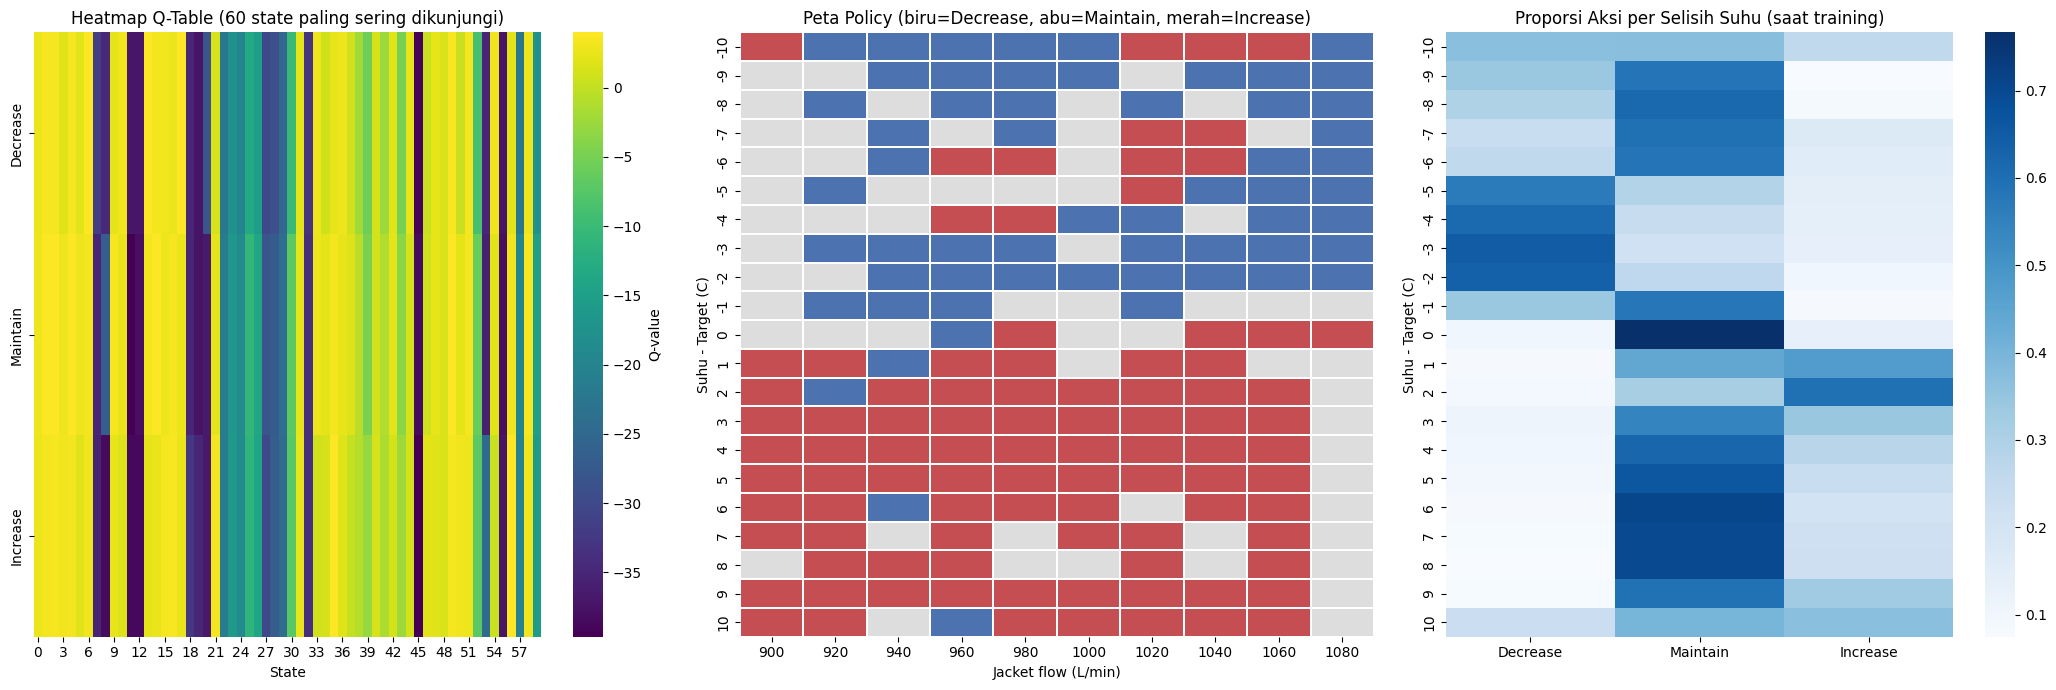

In [ ]:
nama_aksi = ['Decrease', 'Maintain', 'Increase']
total_kunjungan = visit_count.sum(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

# 1. Heatmap Q-table: 60 state paling sering dikunjungi
top = np.argsort(-total_kunjungan)[:60]
sns.heatmap(Q_table[top].T, cmap='viridis', ax=axes[0], yticklabels=nama_aksi,
            cbar_kws={'label': 'Q-value'})
axes[0].set_title('Heatmap Q-Table (60 state paling sering dikunjungi)')
axes[0].set_xlabel('State')

# 2. Peta policy: suhu-target (baris) x flow (kolom) -> aksi terbaik
Q3 = Q_table.reshape(n_bins + [n_actions])
V3 = total_kunjungan.reshape(n_bins)
peta = np.full((n_bins[0], n_bins[1]), np.nan)
for t in range(n_bins[0]):
    for f in range(n_bins[1]):
        bobot = V3[t, f]
        if bobot.sum() > 0:
            peta[t, f] = np.argmax((Q3[t, f] * bobot[..., None]).sum(axis=(0, 1, 2)))
sns.heatmap(peta, cmap=sns.color_palette(['#4c72b0', '#dddddd', '#c44e52']), vmin=0, vmax=2,
            ax=axes[1], cbar=False, xticklabels=np.arange(900, 1100, 20),
            yticklabels=np.arange(-10, 11, 1), linewidths=0.3)
axes[1].set_title('Peta Policy (biru=Decrease, abu=Maintain, merah=Increase)')
axes[1].set_xlabel('Jacket flow (L/min)')
axes[1].set_ylabel('Suhu - Target (C)')

# 3. Proporsi aksi per bin suhu
aksi_per_suhu = visit_count.reshape(n_bins + [n_actions]).sum(axis=(1, 2, 3, 4))
aksi_per_suhu = aksi_per_suhu / np.maximum(aksi_per_suhu.sum(axis=1, keepdims=True), 1)
sns.heatmap(aksi_per_suhu, cmap='Blues', ax=axes[2], xticklabels=nama_aksi,
            yticklabels=np.arange(-10, 11, 1))
axes[2].set_title('Proporsi Aksi per Selisih Suhu (saat training)')
axes[2].set_ylabel('Suhu - Target (C)')

plt.tight_layout()
plt.show()

## Cell 11 — Visualisasi Q-Table

### Fungsi
Membuka "isi kepala" agen: apa yang dia pelajari dan aksi apa yang dia pilih di kondisi tertentu.

### Penjelasan 3 panel
1. **Heatmap Q-Table (60 state paling sering dikunjungi):**
   Baris = 3 aksi, kolom = state. Warna terang berarti Q-value tinggi (aksi itu dianggap bagus). Untuk tiap kolom, aksi dengan warna paling terang adalah pilihan agen di state tersebut.
2. **Peta Policy:**
   Sumbu Y = selisih suhu terhadap target, sumbu X = jacket flow. Warna sel = aksi terbaik: **biru** = Decrease, **abu** = Maintain, **merah** = Increase. Sel kosong berarti state itu tidak pernah dikunjungi.
   Pola yang masuk akal: bila suhu di atas target (baris bawah), dominan merah (naikkan flow); bila suhu di bawah target, dominan biru (turunkan flow); dekat target, abu (pertahankan).
3. **Proporsi aksi per selisih suhu (saat training):**
   Persentase tiap aksi yang dipilih pada tiap tingkat selisih suhu.

### Inti
Q-table adalah "kebijakan" agen dalam bentuk angka. Bagian ini membuktikan agen punya logika yang bisa dijelaskan, tidak seperti kotak hitam.

### Keterbatasan yang terlihat
Hanya sekitar 750 dari 5.670 state yang pernah dikunjungi, karena data historis cuma mencakup sebagian kombinasi kondisi. Untuk state yang belum dikenal, fungsi rekomendasi akan default ke Maintain dan memberi peringatan (Cell 13).

In [ ]:
# Simpan agen ke file .pkl untuk tim WEB
agen_rl = {
    'model_type': 'QLearningAgent (tabular)',
    'model_version': '1.0',
    'trained_at': datetime.datetime.now().isoformat(timespec='seconds'),
    'q_table': Q_table,
    'n_bins': n_bins,
    'bounds': bounds,
    'state_features': fitur,
    'action_labels': {0: 'Decrease Jacket Flow', 1: 'Maintain Jacket Flow', 2: 'Increase Jacket Flow'},
    'env_config': {'target_temp': TARGET_TEMP, 'flow_delta': FLOW_DELTA,
                   'flow_offset_max': FLOW_OFFSET_MAX, 'k_suhu': K_SUHU},
    'hyperparameters': {'alpha': learning_rate, 'gamma': discount_factor,
                        'epsilon_decay': decay_rate, 'episodes': n_episodes},
    'train_ranges': {c: (float(df[c].min()), float(df[c].max())) for c in fitur},
    'train_runs': train_runs, 'test_runs': test_runs,
    'evaluation': tabel_hasil.to_dict('index'),
    'note': 'Hasil dari simulation environment, bukan reactor nyata. Efek action ke suhu adalah ASUMSI simulasi.'
}

with open('rl_agent_batch_reactor.pkl', 'wb') as f:
    pickle.dump(agen_rl, f)
print("Tersimpan: rl_agent_batch_reactor.pkl")

Tersimpan: rl_agent_batch_reactor.pkl


## Cell 12 — Simpan Agen ke File `.pkl`

### Fungsi
Mengemas agen terlatih ke `rl_agent_batch_reactor.pkl` agar bisa dipakai tim WEB tanpa training ulang (PRD bagian 17: model serving).

### Isi file `.pkl`
Satu dictionary yang berisi:
- `q_table`: hasil belajar agen
- `n_bins`, `bounds`: aturan diskretisasi (**wajib sama** antara training dan inference, PRD 17.2)
- `env_config`: target suhu, delta flow, batas, dan efek flow ke suhu
- `action_labels`: arti kode aksi 0/1/2
- `train_ranges`: rentang data training (untuk peringatan input di luar jangkauan)
- `hyperparameters`, `train_runs`, `test_runs`, `evaluation`: dokumentasi
- `model_version`, `trained_at`, `note`: metadata dan catatan bahwa ini hasil simulasi

### Kenapa disimpan bersama metadata?
PRD 17.2 mensyaratkan preprocessing saat inference **identik** dengan saat training. Jika backend memakai bin berbeda, nomor state salah dan rekomendasinya tidak berarti. Karena itu aturan diskretisasi ikut disimpan di dalam model.

### Kenapa `pickle`, bukan format lain?
- PRD menyebut `.pkl` (ilustrasi) dan panduan tugas menyarankan serialisasi sederhana.
- Isinya hanya array dan angka, jadi `pickle` cukup. `joblib` lebih cocok untuk model scikit-learn yang berat.
- Peringatan keamanan: file `.pkl` hanya boleh dimuat dari sumber tepercaya, karena `pickle` bisa menjalankan kode saat dimuat.

### Output
`Tersimpan: rl_agent_batch_reactor.pkl`

In [ ]:
# File fungsi rekomendasi untuk tim WEB (backend tinggal import)
code = '''import pickle
import numpy as np

def load_agent(path="rl_agent_batch_reactor.pkl"):
    with open(path, "rb") as f:
        return pickle.load(f)

def discretize(agent, state):
    cfg = agent["env_config"]
    nilai = [state[0] - cfg["target_temp"], state[1], state[2], state[3], state[4]]
    indices = []
    for val, (low, high), n_bin in zip(nilai, agent["bounds"], agent["n_bins"]):
        normalized = np.clip((val - low) / (high - low), 0, 0.9999)
        indices.append(int(normalized * n_bin))
    return np.ravel_multi_index(indices, agent["n_bins"])

def recommend(agent, state_dict):
    """state_dict: reactor_temp_c, jacket_flow_rate_l_min, pressure_atm,
    reactant_a_conc_mol_l, product_b_conc_mol_l"""
    keys = ["reactor_temp_c", "jacket_flow_rate_l_min", "pressure_atm",
            "reactant_a_conc_mol_l", "product_b_conc_mol_l"]
    hilang = [k for k in keys if k not in state_dict]
    if hilang:
        raise ValueError(f"Field hilang: {hilang}")
    s = np.array([float(state_dict[k]) for k in keys])
    if not np.all(np.isfinite(s)):
        raise ValueError("State tidak valid, simulasi tidak dijalankan")

    cfg = agent["env_config"]
    peringatan = [f"{c} di luar rentang data training"
                  for c, v in zip(agent["state_features"], s)
                  if not (agent["train_ranges"][c][0] <= v <= agent["train_ranges"][c][1])]

    q = agent["q_table"][discretize(agent, s)]
    if q.any():
        aksi = int(np.argmax(q))
    else:
        aksi = 1   # state belum pernah dipelajari -> Maintain
        peringatan.append("State belum pernah dipelajari agen, default Maintain")
    delta = (aksi - 1) * cfg["flow_delta"]
    s_next = s.copy()
    s_next[1] += delta
    s_next[0] -= cfg["k_suhu"] * delta
    error = abs(s_next[0] - cfg["target_temp"])
    reward = -0.5 * error + (1.0 if error <= 2.0 else 0) - (0.05 if aksi != 1 else 0)

    return {
        "recommended_action": {"action_id": aksi, "action_label": agent["action_labels"][aksi]},
        "simulation_result": {"simulated_next_state": dict(zip(keys, map(float, s_next))),
                              "reward": float(reward)},
        "warnings": peringatan,
        "simulation_note": "Hasil berasal dari simulation environment, bukan reactor nyata."}
'''
open('rl_inference.py', 'w').write(code)

# Uji: muat ulang pkl lalu minta rekomendasi
import importlib, rl_inference
importlib.reload(rl_inference)
agent_baru = rl_inference.load_agent('rl_agent_batch_reactor.pkl')

for suhu in [92, 85, 80]:
    contoh = {'reactor_temp_c': suhu, 'jacket_flow_rate_l_min': 1010, 'pressure_atm': 3.2,
              'reactant_a_conc_mol_l': 1.5, 'product_b_conc_mol_l': 1.0}
    hasil_rek = rl_inference.recommend(agent_baru, contoh)
    print(f"Suhu {suhu} C -> {hasil_rek['recommended_action']['action_label']}")
print(json.dumps(hasil_rek, indent=2))

Suhu 92 C -> Increase Jacket Flow
Suhu 85 C -> Maintain Jacket Flow
Suhu 80 C -> Maintain Jacket Flow
{
  "recommended_action": {
    "action_id": 1,
    "action_label": "Maintain Jacket Flow"
  },
  "simulation_result": {
    "simulated_next_state": {
      "reactor_temp_c": 80.0,
      "jacket_flow_rate_l_min": 1010.0,
      "pressure_atm": 3.2,
      "reactant_a_conc_mol_l": 1.5,
      "product_b_conc_mol_l": 1.0
    },
    "reward": -2.5
  },
  "warnings": [],
  "simulation_note": "Hasil berasal dari simulation environment, bukan reactor nyata."
}


## Cell 13 — File `rl_inference.py` untuk Backend dan Uji Muat `.pkl`

### Fungsi
Membuat file Python berisi fungsi siap pakai untuk tim WEB, lalu **menguji** bahwa `.pkl` bisa dimuat ulang dan menghasilkan rekomendasi.

### Fungsi di dalam `rl_inference.py`
| Fungsi | Tugas |
|---|---|
| `load_agent(path)` | Memuat file `.pkl` |
| `discretize(agent, state)` | Mengubah state menjadi nomor baris Q-table (aturan sama dengan training) |
| `recommend(agent, state_dict)` | Fungsi utama untuk endpoint `/recommend` |

### Cara kerja `recommend`
1. **Validasi (PRD 19.1):** field harus lengkap dan angkanya valid (bukan NaN/Infinity). Jika tidak, error dan **simulasi tidak dijalankan**.
2. **Peringatan di luar rentang (PRD 19.3):** jika ada nilai di luar rentang data training, tetap diproses tetapi disertai `warnings`.
3. **Pilih aksi:** ambil Q-value state tersebut lalu `argmax`. Jika state belum pernah dipelajari (semua Q = 0), aksi default **Maintain** dan diberi peringatan.
4. **Simulasikan hasil:** hitung next state dan reward dengan aturan yang sama seperti environment.
5. **Susun response JSON** sesuai draf API PRD 16.2: `recommended_action`, `simulation_result`, `warnings`, dan `simulation_note` ("Hasil berasal dari simulation environment, bukan reactor nyata.").

### Kenapa dipisah ke file `.py`?
Backend tidak perlu menjalankan notebook. Cukup `from rl_inference import load_agent, recommend`. Dengan begitu logika inference terpisah dari logika training.

### Output
Rekomendasi untuk 3 contoh suhu (92, 85, 80 °C) dan satu contoh JSON lengkap. Pada suhu 92 °C agen menyarankan **Increase Jacket Flow** (suhu di atas target), dan pada 85 °C **Maintain**. Pada 80 °C agen menyarankan Maintain meskipun suhu di bawah target; ini hasil belajar agen pada state yang jarang dikunjungi, dan menjadi salah satu keterbatasan Q-Learning tabular dengan data terbatas. Untuk kombinasi kondisi yang belum pernah dikenal agen, hasilnya Maintain disertai peringatan di bagian `warnings`.

In [ ]:
terbaik = tabel_hasil.loc['Agen Q-Learning']
dikunjungi = int((total_kunjungan > 0).sum())

print("=" * 70)
print("RINGKASAN HASIL - RL AGENT BATCH REACTOR (ML Engineer 2)")
print("=" * 70)
print(f"""
1. DATASET
   - {len(df)} baris, {df['Reactor_Run_ID'].nunique()} run | split by Run ID: {len(train_runs)} train / {len(test_runs)} test

2. ENVIRONMENT (SIMULASI - ASUMSI)
   - State : suhu, flow, tekanan, reaktan A, produk B
   - Action: 0 Decrease, 1 Maintain, 2 Increase jacket flow ({FLOW_DELTA} L/min per aksi)
   - Reward: -0.5*|suhu-target| +1 jika dalam +-2 C, penalti kecil ubah flow/mentok
   - Target suhu simulasi {TARGET_TEMP} C (bukan batas keselamatan)
   - Efek flow ke suhu {K_SUHU} C per L/min (asumsi, tidak divalidasi eksperimen)

3. TRAINING Q-LEARNING
   - alpha={learning_rate}, gamma={discount_factor}, decay={decay_rate}, episode={n_episodes}
   - State Q-table: {Q_table.shape[0]} | state dikunjungi: {dikunjungi}
   - Reward/step 500 episode terakhir: {np.mean(rewards_per_episode[-500:]):.3f}

4. EVALUASI (run test)
   - Agen    : reward/step {terbaik.iloc[0]:.3f}, MAE ke target {terbaik.iloc[1]:.2f} C, {terbaik.iloc[2]:.1f}% step dalam +-2 C
   - Tanpa kontrol: MAE {tabel_hasil.loc['Tanpa kontrol (Maintain)'].iloc[1]:.2f} C | Acak: {tabel_hasil.loc['Acak'].iloc[1]:.2f} C | Aturan sederhana: {tabel_hasil.loc['Aturan sederhana'].iloc[1]:.2f} C

5. FILE UNTUK TIM WEB
   - rl_agent_batch_reactor.pkl dan rl_inference.py (fungsi load_agent, recommend)

CATATAN: hasil berasal dari simulation environment, bukan reactor nyata.
         Bukan klaim Safe/Unsafe/defect.
""")

RINGKASAN HASIL - RL AGENT BATCH REACTOR (ML Engineer 2)

1. DATASET
   - 4901 baris, 27 run | split by Run ID: 22 train / 5 test

2. ENVIRONMENT (SIMULASI - ASUMSI)
   - State : suhu, flow, tekanan, reaktan A, produk B
   - Action: 0 Decrease, 1 Maintain, 2 Increase jacket flow (20.0 L/min per aksi)
   - Reward: -0.5*|suhu-target| +1 jika dalam +-2 C, penalti kecil ubah flow/mentok
   - Target suhu simulasi 85.0 C (bukan batas keselamatan)
   - Efek flow ke suhu 0.05 C per L/min (asumsi, tidak divalidasi eksperimen)

3. TRAINING Q-LEARNING
   - alpha=0.2, gamma=0.8, decay=0.0007, episode=8000
   - State Q-table: 5670 | state dikunjungi: 746
   - Reward/step 500 episode terakhir: -1.138

4. EVALUASI (run test)
   - Agen    : reward/step -0.534, MAE ke target 2.59 C, 79.6% step dalam +-2 C
   - Tanpa kontrol: MAE 3.57 C | Acak: 5.26 C | Aturan sederhana: 2.45 C

5. FILE UNTUK TIM WEB
   - rl_agent_batch_reactor.pkl dan rl_inference.py (fungsi load_agent, recommend)

CATATAN: hasil beras

## Cell 14 — Ringkasan Hasil

### Fungsi
Merangkum seluruh pekerjaan RL dalam satu tampilan yang rapi untuk laporan dan presentasi. Semua angka diambil otomatis dari variabel hasil training, jadi tidak perlu diketik manual.

### Isi ringkasan
1. **Dataset:** jumlah baris, jumlah run, pembagian train/test.
2. **Environment:** definisi state, action, reward, target, dan asumsi simulasi.
3. **Training:** hyperparameter, ukuran Q-table, jumlah state yang dikunjungi, reward akhir.
4. **Evaluasi:** perbandingan agen dengan tanpa kontrol, acak, dan aturan sederhana pada run test.
5. **File untuk tim WEB:** `rl_agent_batch_reactor.pkl` dan `rl_inference.py`.

### Poin kunci untuk presentasi
- Agen RL (Q-Learning) belajar menjaga suhu simulasi mendekati target dengan mengatur jacket flow, dan lebih baik daripada tanpa kontrol maupun acak.
- Performa agen mendekati aturan sederhana, belum melampauinya.
- **Semua hasil berasal dari simulation environment**, bukan reaktor nyata.
- Target 85 °C dan efek flow ke suhu adalah **asumsi simulasi** yang perlu disepakati tim (PRD 26.5).
- Sistem **tidak** menyatakan kondisi Safe/Unsafe atau defect, dan anomali tidak sama dengan defect (PRD 10.4).

### Keterbatasan (PRD bagian 21)
- Transisi aksi ke suhu adalah asumsi, bukan hasil eksperimen.
- Hanya sebagian state yang dikunjungi saat training.
- Prediksi suhu dari model ML tidak dipakai dalam state RL (opsional di PRD 11.2).
- Q-Learning tabular butuh diskretisasi; pengembangan berikutnya bisa memakai DQN untuk state kontinu.